# 02 · Aggregate loss simulation

Simulates one future motor policy-year (EUR) from the notebook 01 calibration. Results are saved for 04, 07 and 11.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
require_results('calibrated_model.json')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from insurance_model import (
    CalibratedModel, simulate_aggregate_losses, var, es, capital_proxy,
)


model = CalibratedModel.from_json(result_path('calibrated_model.json'))
print("Loaded calibrated model:")
print(json.dumps(model.__dict__, indent=2))

RNG_SEED = 42
EUR = lambda v: f"EUR {v:,.0f}"

Loaded calibrated model:
{
  "lambda_freq": 0.10239746122016678,
  "r_freq": 0.7569001802967591,
  "threshold": 16793.704399999988,
  "alpha": 0.9899771012425391,
  "mu_body": 6.8229552248309595,
  "sigma_body": 1.0829880227596727,
  "xi_gpd": 0.851939145933323,
  "sigma_gpd": 17465.060318719035,
  "freq_model": "NB2 (exposure-adjusted)",
  "severity_model": "Truncated-Lognormal body + GPD tail (proper POT splice)"
}


## Annual loss

Annual loss is the sum of independent claim severities over an NB2 count at exposure one. Zero-loss years are shown separately from positive losses.

In [2]:
N_SIM_FIRST_LOOK = 500_000
rng = np.random.default_rng(RNG_SEED)
losses = simulate_aggregate_losses(N_SIM_FIRST_LOOK, model, rng)

p_zero = (losses == 0).mean()
print(f"P(S = 0) = {p_zero:.1%}   (no claims that year)")
print(f"Mean annual loss E[S]  = {EUR(losses.mean())}")
print(f"VaR 99.5% (this run)   = {EUR(var(losses, 0.995))}")
print(f"ES  99.5% (this run)   = {EUR(es(losses, 0.995))}   <- treat this one number with caution, see Part 2")

P(S = 0) = 90.9%   (no claims that year)
Mean annual loss E[S]  = EUR 350
VaR 99.5% (this run)   = EUR 6,247
ES  99.5% (this run)   = EUR 45,792   <- treat this one number with caution, see Part 2


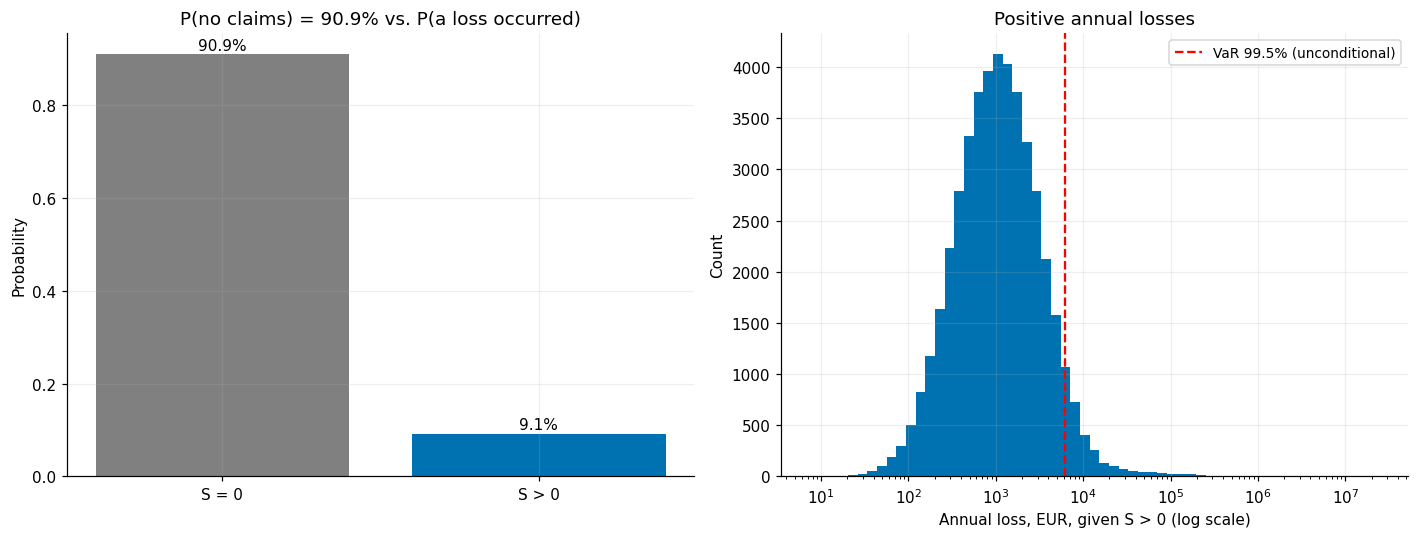

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['S = 0', 'S > 0'], [p_zero, 1 - p_zero], color=['gray', 'C0'])
axes[0].set_ylabel('Probability')
axes[0].set_title(f'P(no claims) = {p_zero:.1%} vs. P(a loss occurred)')
for i, v in enumerate([p_zero, 1-p_zero]):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center')

positive = losses[losses > 0]
axes[1].hist(positive, bins=np.logspace(np.log10(positive.min()), np.log10(positive.max()), 60), color='C0')
axes[1].set_xscale('log')
axes[1].set_xlabel('Annual loss, EUR, given S > 0 (log scale)'); axes[1].set_ylabel('Count')
axes[1].set_title('Positive annual losses')
axes[1].axvline(var(losses, 0.995), color='red', ls='--', label='VaR 99.5% (unconditional)')
axes[1].legend()

plt.tight_layout(); plt.show()

## First-moment check

Analytically E[S] = E[N]·E[X]. Two separate questions follow, and with ξ ≈ 0.85 they have different answers:

1. Is the sampler correct? Tested with checks that do not depend on the heavy tail.
2. How fast does a simulated mean converge to the analytical one? Tested with many independent replicates at several sizes.

In [4]:
from insurance_model import (severity_mean, capped_severity_mean, draw_severities,
                             spliced_severity_cdf, simulate_aggregate_losses)
e_x_analytical = severity_mean(model)
e_s_analytical = model.lambda_freq * e_x_analytical
print(f'Analytical E[X] = EUR {e_x_analytical:,.2f}   E[N] = {model.lambda_freq:.4f}   E[S] = EUR {e_s_analytical:,.2f} per policy-year')
print(f'Finite severity mean: {model.xi_gpd < 1};  finite severity variance: {model.xi_gpd < 0.5}  (xi = {model.xi_gpd:.3f})')

# (1) Sampler checks that survive an infinite-variance tail
n_chk = 1_000_000
x_chk = draw_severities(n_chk, model, np.random.default_rng(7))
ks = stats.kstest(spliced_severity_cdf(x_chk, model), 'uniform')
print(f'\nProbability-integral transform of {n_chk:,} draws vs the spliced CDF: KS statistic {ks.statistic:.4f}, p-value {ks.pvalue:.2f}')

cap_rows = []
for cap in [50_000, 250_000, 1_000_000]:
    capped = np.minimum(x_chk, cap)
    analytic = capped_severity_mean(model, cap)
    se = capped.std(ddof=1) / np.sqrt(n_chk)
    cap_rows.append(dict(cap=cap, analytic_E_min_X_cap=analytic, simulated=capped.mean(),
                         std_error=se, z=(capped.mean() - analytic) / se))
cap_check = pd.DataFrame(cap_rows)
display(cap_check.round(3))
sampler_ok = bool(ks.pvalue > 0.01 and (cap_check['z'].abs() < 3).all())
print('Sampler checks (CDF and capped means):', 'pass' if sampler_ok else 'FAIL')
assert sampler_ok

Analytical E[X] = EUR 2,901.56   E[N] = 0.1024   E[S] = EUR 297.11 per policy-year
Finite severity mean: True;  finite severity variance: False  (xi = 0.852)



Probability-integral transform of 1,000,000 draws vs the spliced CDF: KS statistic 0.0008, p-value 0.59


,cap,analytic_E_min_X_cap,simulated,std_error,z
0,50000,"1,901.492","1,895.765",4.023,-1.424
1,250000,"2,138.006","2,126.435",8.420,-1.374
2,1000000,"2,300.335","2,274.030",14.992,-1.755


Sampler checks (CDF and capped means): pass


The capped mean E[min(X, cap)] has finite variance for every cap, so its Monte Carlo error shrinks like 1/√n and a z-score is meaningful. The uncapped mean has infinite variance, so a z-score is not.

In [5]:
# (2) The seed-42 run used above, as one draw
gap_single = losses.mean() / e_s_analytical - 1
print(f'Seed-42 run, {N_SIM_FIRST_LOOK:,} policy-years: simulated mean EUR {losses.mean():,.2f} vs analytical EUR {e_s_analytical:,.2f} ({gap_single:+.1%})')

# (3) Replicates: severity mean and aggregate mean against N
FM_SIZES = [100_000, 250_000, 500_000, 1_000_000, 2_000_000]
FM_REPS = 40
sev_means, agg_means = {}, {}
for n in FM_SIZES:
    sev_means[n] = np.array([draw_severities(n, model, np.random.default_rng(20_000 + r)).mean() for r in range(FM_REPS)])
    agg_means[n] = np.array([simulate_aggregate_losses(n, model, np.random.default_rng(30_000 + r)).mean() for r in range(FM_REPS)])

def fm_table(means, analytic, what):
    rows = []
    for n in FM_SIZES:
        ratio = means[n] / analytic - 1
        rows.append({'quantity': what, 'N': n, 'median': np.median(ratio), 'p05': np.percentile(ratio, 5),
                     'p95': np.percentile(ratio, 95), 'share_above_analytic': float((ratio > 0).mean()),
                     'mean_over_replicates': ratio.mean()})
    return pd.DataFrame(rows)

fm = pd.concat([fm_table(sev_means, e_x_analytical, 'E[X] per claim (N claims)'),
                fm_table(agg_means, e_s_analytical, 'E[S] per policy-year (N years)')], ignore_index=True)
pct_seed42 = float((agg_means[500_000] < losses.mean()).mean())
print(f'{FM_REPS} replicates per size. Entries are simulated mean / analytical mean - 1.')
print(f'The seed-42 run ({gap_single:+.1%}) sits at the {pct_seed42:.0%} percentile of the 500,000-year replicate distribution.')
display(fm.round(3))

Seed-42 run, 500,000 policy-years: simulated mean EUR 350.43 vs analytical EUR 297.11 (+17.9%)


40 replicates per size. Entries are simulated mean / analytical mean - 1.
The seed-42 run (+17.9%) sits at the 98% percentile of the 500,000-year replicate distribution.


,quantity,N,median,p05,p95,share_above_analytic,mean_over_replicates
0,E[X] per claim (N claims),100000,-0.111,-0.199,0.405,0.200,-0.032
1,E[X] per claim (N claims),250000,-0.111,-0.188,0.068,0.125,-0.098
2,E[X] per claim (N claims),500000,-0.095,-0.164,0.128,0.175,-0.064
3,E[X] per claim (N claims),1000000,-0.104,-0.152,0.106,0.100,-0.078
4,E[X] per claim (N claims),2000000,-0.082,-0.129,0.250,0.175,-0.041
5,E[S] per policy-year (N years),100000,-0.177,-0.259,0.221,0.150,-0.032
6,E[S] per policy-year (N years),250000,-0.123,-0.255,1.111,0.250,0.057
7,E[S] per policy-year (N years),500000,-0.170,-0.217,0.028,0.125,-0.117
8,E[S] per policy-year (N years),1000000,-0.117,-0.199,0.179,0.175,0.079
9,E[S] per policy-year (N years),2000000,-0.123,-0.177,0.184,0.150,-0.090


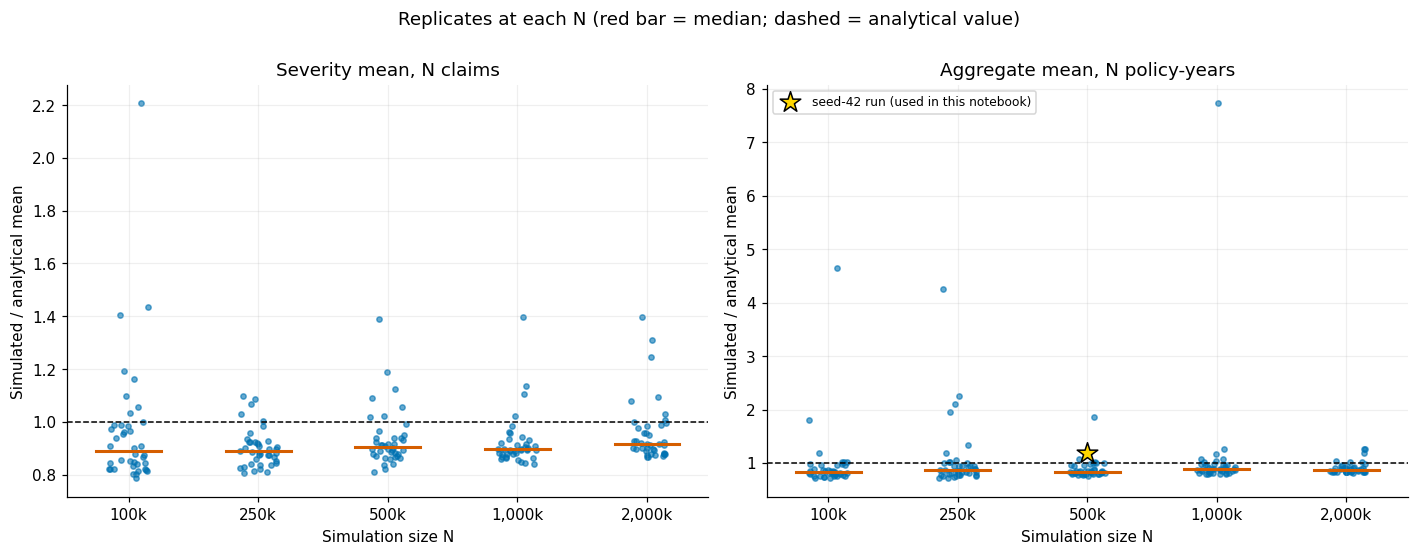

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, means, analytic, title in [(axes[0], sev_means, e_x_analytical, 'Severity mean, N claims'),
                                    (axes[1], agg_means, e_s_analytical, 'Aggregate mean, N policy-years')]:
    for k, n in enumerate(FM_SIZES):
        ratio = means[n] / analytic
        ax.scatter(np.full(len(ratio), k) + np.random.default_rng(k).uniform(-0.15, 0.15, len(ratio)), ratio,
                   s=12, alpha=0.6, color='C0')
        ax.plot([k - 0.25, k + 0.25], [np.median(ratio)] * 2, color='C3', lw=2)
    ax.axhline(1, color='k', ls='--', lw=1)
    ax.set_xticks(range(len(FM_SIZES))); ax.set_xticklabels([f'{n/1000:,.0f}k' for n in FM_SIZES])
    ax.set_xlabel('Simulation size N'); ax.set_ylabel('Simulated / analytical mean')
    ax.set_title(title)
axes[1].scatter([2], [losses.mean() / e_s_analytical], marker='*', s=200, color='gold', edgecolor='k', zorder=5,
                label='seed-42 run (used in this notebook)')
axes[1].legend(fontsize=8)
plt.suptitle('Replicates at each N (red bar = median; dashed = analytical value)', y=1.0)
plt.tight_layout(); plt.show()

In [7]:
big = fm[fm['N'] == FM_SIZES[-1]].set_index('quantity')
sev_row, agg_row = big.iloc[0], big.iloc[1]
bands_cover = {q: bool(r.p05 <= 0 <= r.p95) for q, r in big.iterrows()}
print(f'At N = {FM_SIZES[-1]:,}: severity median {sev_row["median"]:+.1%} (90% band {sev_row.p05:+.1%} to {sev_row.p95:+.1%}); '
      f'aggregate median {agg_row["median"]:+.1%} (90% band {agg_row.p05:+.1%} to {agg_row.p95:+.1%})')
print('Analytical value inside the 90% replicate band at the largest N:', bands_cover)
print('Label: heavy-tail Monte Carlo instability despite a finite theoretical mean.')

At N = 2,000,000: severity median -8.2% (90% band -12.9% to +25.0%); aggregate median -12.3% (90% band -17.7% to +18.4%)
Analytical value inside the 90% replicate band at the largest N: {'E[X] per claim (N claims)': True, 'E[S] per policy-year (N years)': True}
Label: heavy-tail Monte Carlo instability despite a finite theoretical mean.


**Reading the results.**

- The sampler is correct. The probability-integral transform of 1,000,000 draws passes a KS test against the spliced CDF (p = 0.59), and Monte Carlo means of the capped severity agree with their closed forms to within about two standard errors (caps of EUR 50k, 250k, 1m).
- The uncapped mean does not behave like a sample mean with finite variance. At every N from 100k to 2m the replicate median is below the analytical value (8–11% for the severity, 12–18% for the aggregate), while 10–25% of replicates land above it, sometimes far above (aggregate at N = 250k: 95th percentile +111%).
- The seed-42 run used in this notebook (+17.9%) is one of those upward jumps, at the 98th percentile of the 500k-year replicates. Its ES 99.5% is high for the same reason (see the ES column of the sensitivity table further down).

**Conclusion: heavy-tail Monte Carlo instability despite a finite theoretical mean.** Uncapped Monte Carlo neither confirms nor refutes E[S] = E[N]·E[X] at these sample sizes; the analytical value rests on the closed form, and the sampler is validated separately by the CDF and capped-mean checks. Anything computed from the simulated mean or from ES inherits this instability; VaR 99.5% is much more stable. Figures in later notebooks use the analytical mean wherever one exists.

## Monte Carlo sensitivity

30 seeds at each sample size, model parameters fixed. The spread shows run-to-run noise only, not calibration or model uncertainty.

In [8]:
sizes = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
N_REPLICATES = 30

records = []
for n in sizes:
    for rep in range(N_REPLICATES):
        rng_r = np.random.default_rng(10_000 + rep)
        l = simulate_aggregate_losses(n, model, rng_r)
        records.append(dict(n=n, rep=rep, VaR995=var(l, 0.995), ES995=es(l, 0.995)))

conv = pd.DataFrame(records)
conv_summary = conv.groupby('n').agg(
    VaR_mean=('VaR995', 'mean'), VaR_std=('VaR995', 'std'),
    ES_mean=('ES995', 'mean'), ES_std=('ES995', 'std'),
).reset_index()
conv_summary['VaR_cv'] = conv_summary['VaR_std'] / conv_summary['VaR_mean']
conv_summary['ES_cv'] = conv_summary['ES_std'] / conv_summary['ES_mean']
conv_summary.round(1)

,n,VaR_mean,VaR_std,ES_mean,ES_std,VaR_cv,ES_cv
0,10000,"6,370.500",448.400,"22,821.300","10,716.400",0.100,0.500
1,25000,"6,235.500",294.900,"24,146.000","7,901.100",0.000,0.300
2,50000,"6,267.200",283.900,"35,952.500","57,564.100",0.000,1.600
3,100000,"6,256.400",184.400,"35,058.800","55,649.200",0.000,1.600
4,250000,"6,235.600",101.400,"30,322.700","18,746.500",0.000,0.600
5,500000,"6,261.300",73.500,"27,914.300","5,994.000",0.000,0.200
6,1000000,"6,269.800",60.300,"33,883.000","12,538.600",0.000,0.400


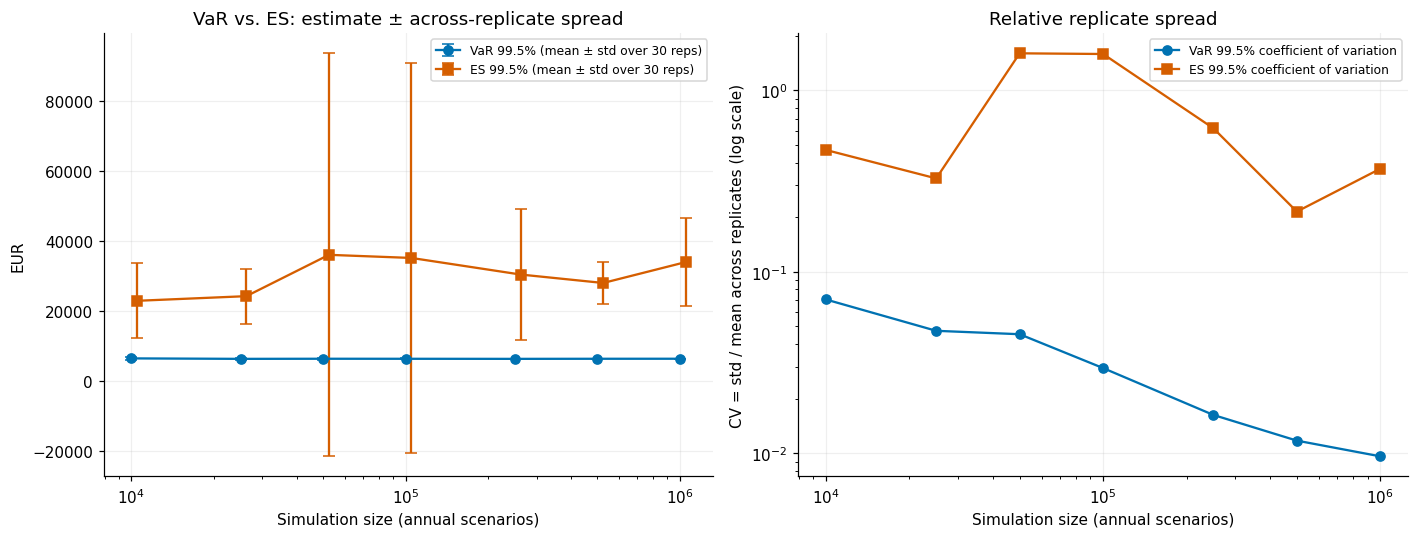

      n  VaR_cv  ES_cv
  10000   0.070  0.470
  25000   0.047  0.327
  50000   0.045  1.601
 100000   0.029  1.587
 250000   0.016  0.618
 500000   0.012  0.215
1000000   0.010  0.370


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(conv_summary['n'], conv_summary['VaR_mean'], yerr=conv_summary['VaR_std'],
                  fmt='o-', capsize=4, color='C0', label='VaR 99.5% (mean ± std over 30 reps)')
axes[0].errorbar(conv_summary['n']*1.05, conv_summary['ES_mean'], yerr=conv_summary['ES_std'],
                  fmt='s-', capsize=4, color='C3', label='ES 99.5% (mean ± std over 30 reps)')
axes[0].set_xscale('log')
axes[0].set_xlabel('Simulation size (annual scenarios)'); axes[0].set_ylabel('EUR')
axes[0].set_title('VaR vs. ES: estimate ± across-replicate spread')
axes[0].legend(fontsize=8)

axes[1].plot(conv_summary['n'], conv_summary['VaR_cv'], 'o-', color='C0', label='VaR 99.5% coefficient of variation')
axes[1].plot(conv_summary['n'], conv_summary['ES_cv'], 's-', color='C3', label='ES 99.5% coefficient of variation')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Simulation size (annual scenarios)'); axes[1].set_ylabel('CV = std / mean across replicates (log scale)')
axes[1].set_title('Relative replicate spread')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(conv_summary[['n','VaR_cv','ES_cv']].round(4).to_string(index=False))

A small VaR spread doesn't mean ES is precise; ES depends on the rarest, largest losses.

More simulations reduce sampling error and nothing else. Parameter uncertainty needs refitting, and model uncertainty needs different assumptions.

## Risk measures

VaR and ES for one policy-year. The unexpected-loss proxy is VaR 99.5% minus the analytical mean; it is not a regulatory capital figure.

In [10]:
N_SIM = 500_000
rng_final = np.random.default_rng(RNG_SEED)
losses_final = simulate_aggregate_losses(N_SIM, model, rng_final)

mean_loss = losses_final.mean()
v995 = var(losses_final, 0.995)
e995 = es(losses_final, 0.995)
k995 = v995 - e_s_analytical

summary = pd.DataFrame({
    'Metric': ['Simulated mean, seed-42 run (analytical mean is 297)', 'VaR 99.5% (annual-loss quantile)',
               'ES 99.5% (use as order-of-magnitude only, see Part 2)',
               'Economic-capital proxy K_99.5 = VaR - E[S]  (NOT a Solvency II SCR)'],
    'Value (EUR, rounded)': [f"{mean_loss:,.0f}", f"{v995:,.0f}", f"~{e995/1000:.0f}k", f"{k995:,.0f}"],
})
summary

,Metric,"Value (EUR, rounded)"
0,"Simulated mean, seed-42 run (analytical mean i...",350
1,VaR 99.5% (annual-loss quantile),"6,247"
2,"ES 99.5% (use as order-of-magnitude only, see ...",~46k
3,Economic-capital proxy K_99.5 = VaR - E[S] (N...,"5,950"


In [11]:
json.dump({
    'n_sim': N_SIM, 'seed': RNG_SEED,
    'mean_loss': float(mean_loss), 'analytical_mean_loss': float(e_s_analytical),
    'currency': 'EUR', 'exposure': 1.0, 'horizon': 'one policy-year', 'var_995': float(v995),
    'es_995': float(e995), 'capital_proxy_995': float(k995),
    'p_zero': float((losses_final == 0).mean()),
    'es_995_replicates_500k': {
        'n_replicates': int((conv.n == 500_000).sum()),
        'median': float(conv.loc[conv.n == 500_000, 'ES995'].median()),
        'p05': float(conv.loc[conv.n == 500_000, 'ES995'].quantile(0.05)),
        'p95': float(conv.loc[conv.n == 500_000, 'ES995'].quantile(0.95)),
    },
    'first_moment_check': {
        'label': 'Heavy-tail Monte Carlo instability despite a finite theoretical mean',
        'analytical_severity_mean': float(e_x_analytical),
        'sampler_ks_pvalue': float(ks.pvalue),
        'capped_mean_z': [float(z) for z in cap_check['z']],
        'seed42_percentile_in_500k_replicates': pct_seed42,
        'replicates': fm.to_dict('records'),
    },
    'note': 'ES_995 has high Monte Carlo variance under this fitted tail (xi~0.85); see Part 2 convergence study.',
}, open(result_path('loss_summary.json'), 'w'), indent=2)
print("Saved results/aggregate/loss_summary.json")

Saved results/aggregate/loss_summary.json


## Notes

- 90.9% of policy-years have no claim. The analytical mean loss is EUR 297.11 (closed form).
- The seed-42 simulated mean (EUR 350) is an upward outlier: 98th percentile of the 500k-year replicates, whose medians sit 12–18% below the analytical mean. Heavy-tail Monte Carlo instability despite a finite theoretical mean; the sampler itself passes the CDF and capped-mean checks.
- VaR 99.5% is EUR 6,247 (replicate CV about 1% at 500k years). The capital proxy K = VaR − analytical mean is EUR 5,950.
- ES 99.5% in the saved run is EUR 45,792, well above the replicates (mean about 28k with standard deviation about 6k at 500k years; about 34k ± 13k at 1m). Read ES as an order of magnitude only.
- Parameter uncertainty in the heavy tail is not part of this simulation (see notebook 11).

In [12]:
record_results('loss_summary.json')